# Brain Tumor Dataset - Exploratory Data Analysis

This notebook implements the exploratory data analysis described in **Section 3.1.2** of the thesis.

We analyze the Brain Tumor MRI dataset by computing three key metrics:

1. **Mean Intensity**: Average pixel value reflecting overall brightness
   $$\bar{I} = \frac{1}{P} \sum_{i=1}^{P} I_i$$

2. **Standard Deviation**: Spread of pixel values indicating contrast
   $$\sigma = \sqrt{\frac{1}{P} \sum_{i=1}^{P} (I_i - \bar{I})^2}$$

3. **Entropy**: Information content indicating complexity/texture
   $$H = -\sum_{j=1}^{J} p_j \log p_j$$

where $I_i$ are grayscale intensities, $P$ is the total number of pixels, and $p_j$ is the probability of intensities in bin $j$.

In [21]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import entropy
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import os

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

# Create output directory for saving results
output_dir = Path("outputs/brain_tumor_eda")
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported successfully")
print(f"✓ Output directory created: {output_dir}")

✓ Libraries imported successfully
✓ Output directory created: outputs/brain_tumor_eda


## 1. Load the Dataset

We load the Brain Tumor dataset using our custom dataloader, which applies the preprocessing pipeline:
- Convert to RGB
- Resize to 64×64 pixels
- Normalize to [0, 1] range

In [22]:
# Import our custom dataset loader
from fedaug.data_loader import BrainTumorDataset, get_dataset_info

# Load the dataset
dataset = BrainTumorDataset(root="../data/brain_tumor_dataset")

# Display dataset information
info = get_dataset_info(root="../data/brain_tumor_dataset")
print("Dataset Information:")
print("=" * 50)
for key, value in info.items():
    print(f"{key:20s}: {value}")

print(f"\n✓ Loaded {len(dataset)} images")

Dataset Information:
total_samples       : 253
num_classes         : 2
classes             : ['no', 'yes']
class_to_idx        : {'no': 0, 'yes': 1}
class_distribution  : {'no': np.int64(98), 'yes': np.int64(155)}
image_shape         : (3, 64, 64)
value_range         : [0, 1] (normalized)

✓ Loaded 253 images


## 2. Define Metric Computation Functions

Following the thesis specifications, we implement functions to compute:
- Mean Intensity (brightness)
- Standard Deviation (contrast)
- Entropy (complexity/texture)

In [23]:
def compute_mean_intensity(image_tensor):
    """
    Compute mean intensity of an image.
    
    Formula: I_bar = (1/P) * sum(I_i)
    
    Args:
        image_tensor: PyTorch tensor of shape (3, 64, 64) in range [0, 1]
    
    Returns:
        float: Mean intensity value
    """
    # Convert to grayscale for intensity measurement
    # Using standard RGB to grayscale weights: 0.299R + 0.587G + 0.114B
    grayscale = 0.299 * image_tensor[0] + 0.587 * image_tensor[1] + 0.114 * image_tensor[2]
    return float(grayscale.mean())


def compute_std_deviation(image_tensor):
    """
    Compute standard deviation of pixel intensities.
    
    Formula: sigma = sqrt((1/P) * sum((I_i - I_bar)^2))
    
    Args:
        image_tensor: PyTorch tensor of shape (3, 64, 64) in range [0, 1]
    
    Returns:
        float: Standard deviation value
    """
    # Convert to grayscale
    grayscale = 0.299 * image_tensor[0] + 0.587 * image_tensor[1] + 0.114 * image_tensor[2]
    return float(grayscale.std())


def compute_entropy(image_tensor, num_bins=256):
    """
    Compute entropy of the intensity histogram.
    
    Formula: H = -sum(p_j * log(p_j))
    
    Args:
        image_tensor: PyTorch tensor of shape (3, 64, 64) in range [0, 1]
        num_bins: Number of bins for histogram (default: 256)
    
    Returns:
        float: Entropy value (in nats, using natural logarithm)
    """
    # Convert to grayscale
    grayscale = 0.299 * image_tensor[0] + 0.587 * image_tensor[1] + 0.114 * image_tensor[2]
    
    # Compute histogram
    hist, _ = np.histogram(grayscale.numpy().flatten(), bins=num_bins, range=(0, 1))
    
    # Compute probabilities (p_j)
    hist = hist + 1e-10  # Add small epsilon to avoid log(0)
    probabilities = hist / hist.sum()
    
    # Compute entropy
    return float(entropy(probabilities))


print("✓ Metric computation functions defined")

✓ Metric computation functions defined


## 3. Compute Metrics for All Images

We compute the three key metrics for every image in the dataset, separated by class:
- Class 0: No tumor
- Class 1: Tumor present

In [24]:
# Initialize lists to store metrics
metrics_data = {
    'mean_intensity': [],
    'std_deviation': [],
    'entropy': [],
    'label': [],
    'class_name': []
}

print("Computing metrics for all images...")
print("This may take a minute...\n")

# Compute metrics for each image
for idx in tqdm(range(len(dataset)), desc="Processing images"):
    image, label = dataset[idx]
    
    # Compute metrics
    mean_int = compute_mean_intensity(image)
    std_dev = compute_std_deviation(image)
    ent = compute_entropy(image)
    
    # Store results
    metrics_data['mean_intensity'].append(mean_int)
    metrics_data['std_deviation'].append(std_dev)
    metrics_data['entropy'].append(ent)
    metrics_data['label'].append(label)
    metrics_data['class_name'].append(dataset.classes[label])

# Convert to DataFrame for easier analysis
df = pd.DataFrame(metrics_data)

print("\n✓ Metrics computed for all images")
print(f"\nDataset shape: {df.shape}")
print("\nFirst few rows:")
display(df.head())

Computing metrics for all images...
This may take a minute...



Processing images: 100%|██████████| 253/253 [00:00<00:00, 867.38it/s]


✓ Metrics computed for all images

Dataset shape: (253, 5)

First few rows:


,mean_intensity,std_deviation,entropy,label,class_name
0,0.116516,0.125437,3.706083,0,no
1,0.183150,0.151200,4.176637,0,no
2,0.071464,0.129034,2.184791,0,no
3,0.155036,0.195976,2.813728,0,no
4,0.119975,0.168764,3.120467,0,no


## 4. Statistical Summary

Let's examine the summary statistics for each metric, grouped by class.

In [25]:
# Summary statistics by class
print("Summary Statistics by Class")
print("=" * 80)
print("\nClass 0 (No Tumor):")
print(df[df['label'] == 0][['mean_intensity', 'std_deviation', 'entropy']].describe())

print("\n" + "=" * 80)
print("\nClass 1 (Tumor Present):")
print(df[df['label'] == 1][['mean_intensity', 'std_deviation', 'entropy']].describe())

print("\n" + "=" * 80)
print("\nComparison of Means:")
comparison = df.groupby('class_name')[['mean_intensity', 'std_deviation', 'entropy']].mean()
print(comparison)

print("\n" + "=" * 80)
print("\nKey Observations:")
print(f"- Mean intensity is {'HIGHER' if comparison.loc['yes', 'mean_intensity'] > comparison.loc['no', 'mean_intensity'] else 'LOWER'} for tumor images")
print(f"- Standard deviation is {'HIGHER' if comparison.loc['yes', 'std_deviation'] > comparison.loc['no', 'std_deviation'] else 'LOWER'} for tumor images")
print(f"- Entropy is {'HIGHER' if comparison.loc['yes', 'entropy'] > comparison.loc['no', 'entropy'] else 'LOWER'} for tumor images")
print(f"\nMinimum std deviation: {df['std_deviation'].min():.4f} (all images have sufficient contrast)")

Summary Statistics by Class

Class 0 (No Tumor):
       mean_intensity  std_deviation    entropy
count       98.000000      98.000000  98.000000
mean         0.204060       0.185172   3.827658
std          0.081900       0.050307   0.531745
min          0.071464       0.094987   2.184791
25%          0.142634       0.151200   3.580814
50%          0.194137       0.176760   3.765236
75%          0.224620       0.201816   4.227032
max          0.632225       0.383251   4.926386


Class 1 (Tumor Present):
       mean_intensity  std_deviation     entropy
count      155.000000     155.000000  155.000000
mean         0.276221       0.208039    4.392197
std          0.084264       0.041506    0.459983
min          0.133178       0.132655    2.571633
25%          0.213588       0.172687    4.136507
50%          0.261611       0.207125    4.396941
75%          0.333758       0.235512    4.699007
max          0.562856       0.315676    5.262215


Comparison of Means:
            mean_intensity  

## 5. Visualizations

We create 6 plots as specified:
1. **Histogram of Mean Intensity**
2. **Box Plot of Mean Intensity**
3. **Histogram of Standard Deviation**
4. **Box Plot of Standard Deviation**
5. **Histogram of Entropy**
6. **Box Plot of Entropy**

These visualizations correspond to **Figure 2** in the thesis.

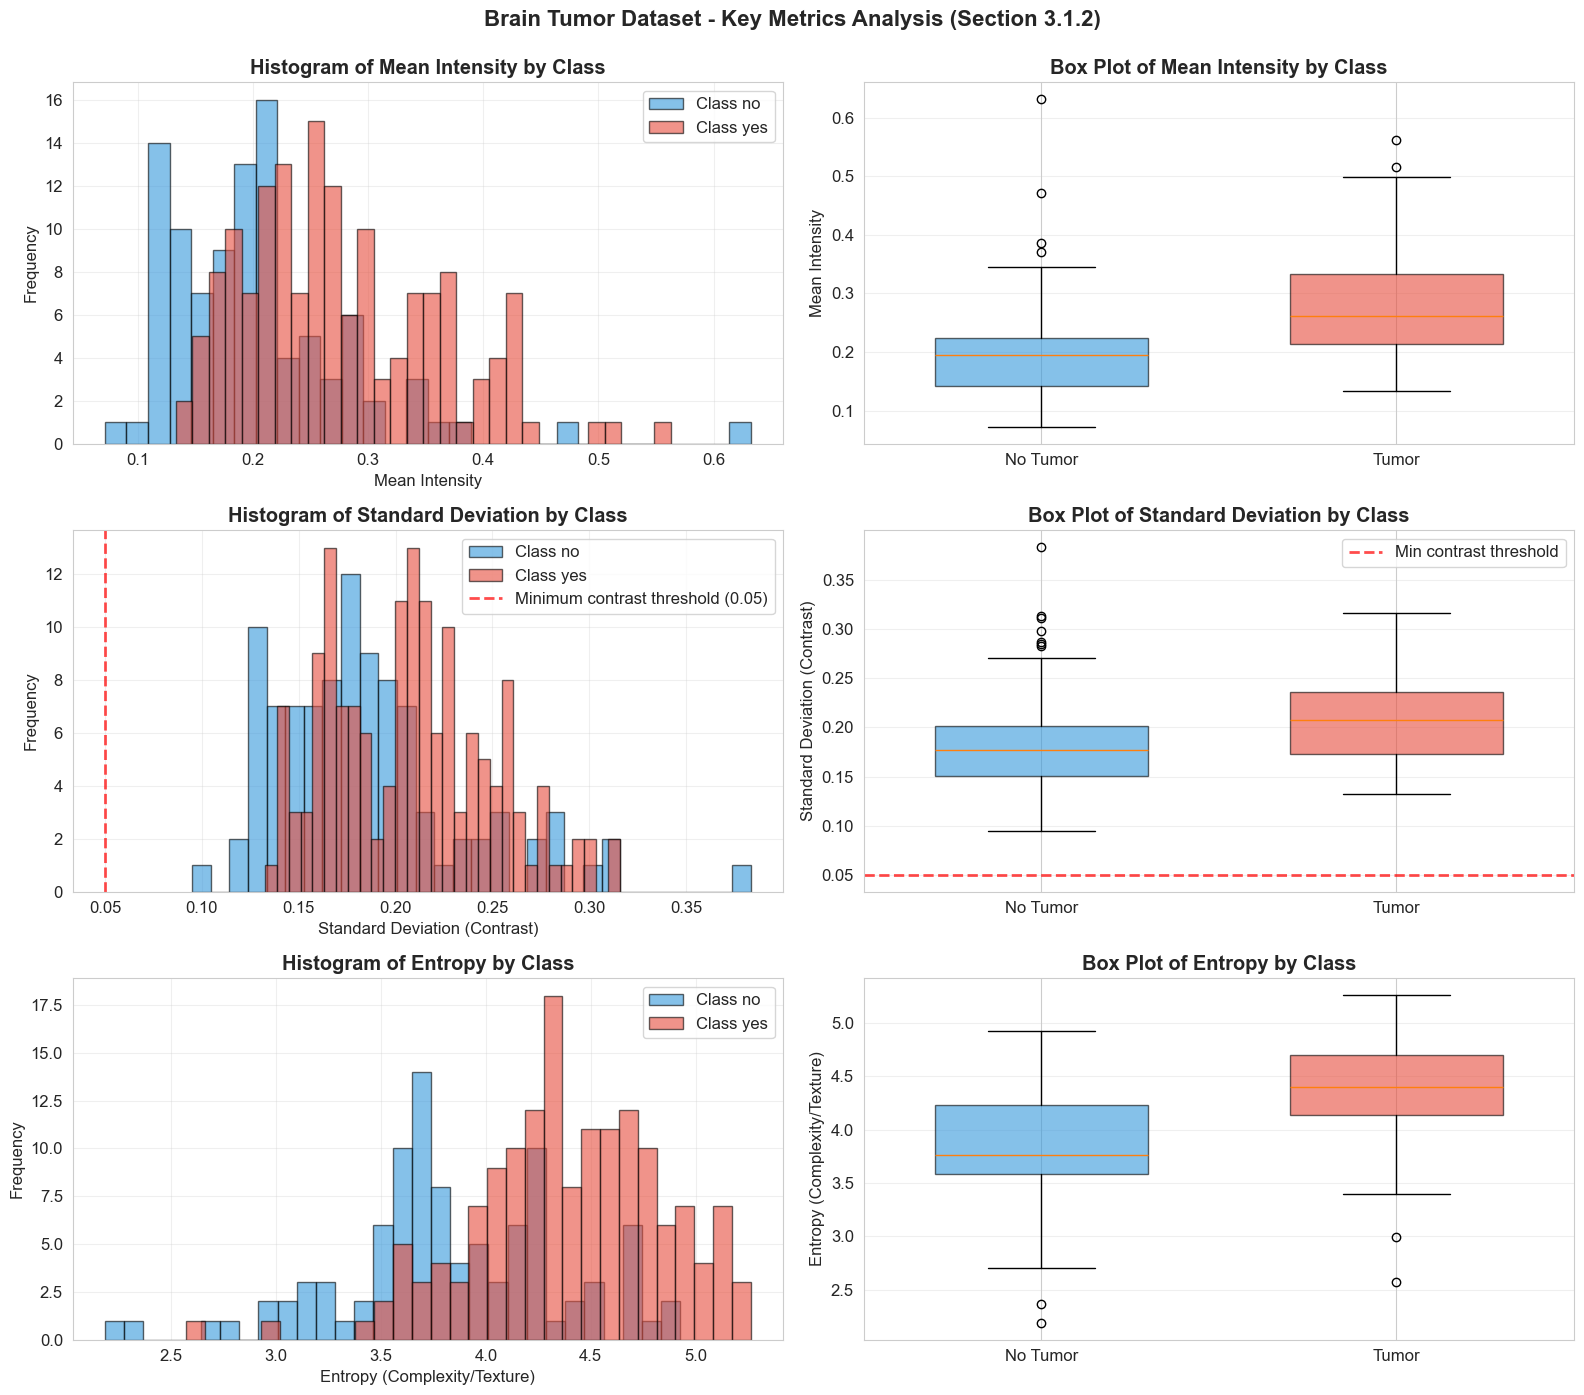


✓ Figure 2 (Thesis Section 3.1.2) created and saved as 'outputs/brain_tumor_eda/brain_tumor_eda_figure2.png'


In [26]:
# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Brain Tumor Dataset - Key Metrics Analysis (Section 3.1.2)', 
             fontsize=16, fontweight='bold', y=0.995)

# Define colors for each class
colors = {'no': '#3498db', 'yes': '#e74c3c'}  # Blue for no tumor, Red for tumor

# ==========================================
# ROW 1: Mean Intensity
# ==========================================

# 1. Histogram of Mean Intensity
ax = axes[0, 0]
for class_name in ['no', 'yes']:
    data = df[df['class_name'] == class_name]['mean_intensity']
    ax.hist(data, bins=30, alpha=0.6, label=f'Class {class_name}', 
            color=colors[class_name], edgecolor='black')
ax.set_xlabel('Mean Intensity')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Mean Intensity by Class', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Box Plot of Mean Intensity
ax = axes[0, 1]
box_data = [df[df['class_name'] == 'no']['mean_intensity'],
            df[df['class_name'] == 'yes']['mean_intensity']]
bp = ax.boxplot(box_data, tick_labels=['No Tumor', 'Tumor'], 
                patch_artist=True, widths=0.6)
for patch, class_name in zip(bp['boxes'], ['no', 'yes']):
    patch.set_facecolor(colors[class_name])
    patch.set_alpha(0.6)
ax.set_ylabel('Mean Intensity')
ax.set_title('Box Plot of Mean Intensity by Class', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ==========================================
# ROW 2: Standard Deviation
# ==========================================

# 3. Histogram of Standard Deviation
ax = axes[1, 0]
for class_name in ['no', 'yes']:
    data = df[df['class_name'] == class_name]['std_deviation']
    ax.hist(data, bins=30, alpha=0.6, label=f'Class {class_name}', 
            color=colors[class_name], edgecolor='black')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, 
           label='Minimum contrast threshold (0.05)', alpha=0.7)
ax.set_xlabel('Standard Deviation (Contrast)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Standard Deviation by Class', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Box Plot of Standard Deviation
ax = axes[1, 1]
box_data = [df[df['class_name'] == 'no']['std_deviation'],
            df[df['class_name'] == 'yes']['std_deviation']]
bp = ax.boxplot(box_data, tick_labels=['No Tumor', 'Tumor'], 
                patch_artist=True, widths=0.6)
for patch, class_name in zip(bp['boxes'], ['no', 'yes']):
    patch.set_facecolor(colors[class_name])
    patch.set_alpha(0.6)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=2, 
           label='Min contrast threshold', alpha=0.7)
ax.set_ylabel('Standard Deviation (Contrast)')
ax.set_title('Box Plot of Standard Deviation by Class', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# ==========================================
# ROW 3: Entropy
# ==========================================

# 5. Histogram of Entropy
ax = axes[2, 0]
for class_name in ['no', 'yes']:
    data = df[df['class_name'] == class_name]['entropy']
    ax.hist(data, bins=30, alpha=0.6, label=f'Class {class_name}', 
            color=colors[class_name], edgecolor='black')
ax.set_xlabel('Entropy (Complexity/Texture)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Entropy by Class', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Box Plot of Entropy
ax = axes[2, 1]
box_data = [df[df['class_name'] == 'no']['entropy'],
            df[df['class_name'] == 'yes']['entropy']]
bp = ax.boxplot(box_data, tick_labels=['No Tumor', 'Tumor'], 
                patch_artist=True, widths=0.6)
for patch, class_name in zip(bp['boxes'], ['no', 'yes']):
    patch.set_facecolor(colors[class_name])
    patch.set_alpha(0.6)
ax.set_ylabel('Entropy (Complexity/Texture)')
ax.set_title('Box Plot of Entropy by Class', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Adjust layout and save
plt.tight_layout()
output_file = output_dir / 'brain_tumor_eda_figure2.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure 2 (Thesis Section 3.1.2) created and saved as '{output_file}'")

## 6. Interpretation and Conclusions

Based on the key metrics analysis (as described in thesis Section 3.1.2):

In [27]:
# Calculate and display key findings
print("CONCLUSIONS (Thesis Section 3.1.2)")
print("=" * 80)

# Mean comparisons
mean_no = df[df['label'] == 0]['mean_intensity'].mean()
mean_yes = df[df['label'] == 1]['mean_intensity'].mean()
std_no = df[df['label'] == 0]['std_deviation'].mean()
std_yes = df[df['label'] == 1]['std_deviation'].mean()
ent_no = df[df['label'] == 0]['entropy'].mean()
ent_yes = df[df['label'] == 1]['entropy'].mean()

print("\n1. MEAN INTENSITY (Brightness):")
print(f"   - Class 0 (No Tumor):    {mean_no:.4f}")
print(f"   - Class 1 (Tumor):       {mean_yes:.4f}")
print(f"   - Difference:            {abs(mean_yes - mean_no):.4f} ({((mean_yes - mean_no) / mean_no * 100):+.2f}%)")
print(f"   → Tumor images are {'BRIGHTER' if mean_yes > mean_no else 'DARKER'} on average")

print("\n2. STANDARD DEVIATION (Contrast):")
print(f"   - Class 0 (No Tumor):    {std_no:.4f}")
print(f"   - Class 1 (Tumor):       {std_yes:.4f}")
print(f"   - Difference:            {abs(std_yes - std_no):.4f} ({((std_yes - std_no) / std_no * 100):+.2f}%)")
print(f"   - Minimum σ in dataset:  {df['std_deviation'].min():.4f}")
print(f"   → Tumor images have {'HIGHER' if std_yes > std_no else 'LOWER'} contrast")
print(f"   → All images have σ > 0.05, indicating sufficient contrast for training")

print("\n3. ENTROPY (Complexity/Texture):")
print(f"   - Class 0 (No Tumor):    {ent_no:.4f}")
print(f"   - Class 1 (Tumor):       {ent_yes:.4f}")
print(f"   - Difference:            {abs(ent_yes - ent_no):.4f} ({((ent_yes - ent_no) / ent_no * 100):+.2f}%)")
print(f"   → Tumor images have {'MORE' if ent_yes > ent_no else 'LESS'} complex textures")

print("\n" + "=" * 80)
print("\nOVERALL CONCLUSIONS:")
print("\n✓ The Brain Tumor dataset is SUITABLE for model training because:")
print("  1. All images have sufficient contrast (σ > 0.05)")
print("  2. Images contain sufficient complexity to learn from")
print("  3. Clear differences in metrics between classes suggest distinguishability")
print("  4. Tumor images show higher brightness, contrast, and complexity")
print("     (expected due to tumors introducing irregularities in tissue structure)")
print("\n✓ The model should be able to learn to distinguish between")
print("  images with and without tumors based on these metric differences.")
print("\n" + "=" * 80)

CONCLUSIONS (Thesis Section 3.1.2)

1. MEAN INTENSITY (Brightness):
   - Class 0 (No Tumor):    0.2041
   - Class 1 (Tumor):       0.2762
   - Difference:            0.0722 (+35.36%)
   → Tumor images are BRIGHTER on average

2. STANDARD DEVIATION (Contrast):
   - Class 0 (No Tumor):    0.1852
   - Class 1 (Tumor):       0.2080
   - Difference:            0.0229 (+12.35%)
   - Minimum σ in dataset:  0.0950
   → Tumor images have HIGHER contrast
   → All images have σ > 0.05, indicating sufficient contrast for training

3. ENTROPY (Complexity/Texture):
   - Class 0 (No Tumor):    3.8277
   - Class 1 (Tumor):       4.3922
   - Difference:            0.5645 (+14.75%)
   → Tumor images have MORE complex textures


OVERALL CONCLUSIONS:

✓ The Brain Tumor dataset is SUITABLE for model training because:
  1. All images have sufficient contrast (σ > 0.05)
  2. Images contain sufficient complexity to learn from
  3. Clear differences in metrics between classes suggest distinguishability
  4. Tu

## 7. Additional Analysis: Sample Images

Let's visualize a few sample images from each class to qualitatively verify our quantitative findings.

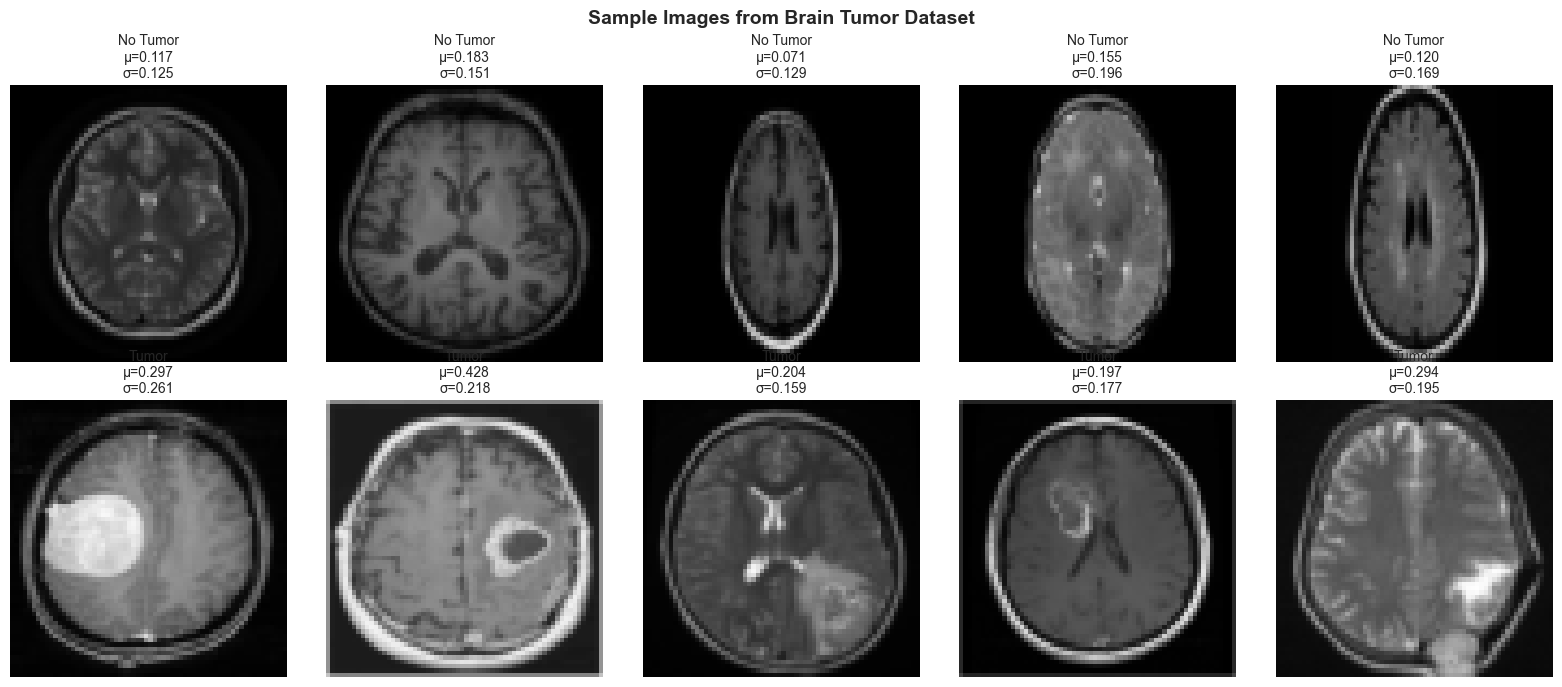

✓ Sample images displayed and saved as 'outputs/brain_tumor_eda/brain_tumor_samples.png'


In [28]:
# Show sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images from Brain Tumor Dataset', fontsize=14, fontweight='bold')

# Get indices for each class
no_tumor_indices = df[df['label'] == 0].index[:5]
tumor_indices = df[df['label'] == 1].index[:5]

# Plot Class 0 (No Tumor)
for i, idx in enumerate(no_tumor_indices):
    img, label = dataset[int(idx)]
    # Convert tensor to numpy and transpose to (H, W, C)
    img_np = img.numpy().transpose(1, 2, 0)
    
    axes[0, i].imshow(img_np)
    axes[0, i].axis('off')
    axes[0, i].set_title(f"No Tumor\nμ={df.loc[idx, 'mean_intensity']:.3f}\nσ={df.loc[idx, 'std_deviation']:.3f}", 
                         fontsize=10)

# Plot Class 1 (Tumor)
for i, idx in enumerate(tumor_indices):
    img, label = dataset[int(idx)]
    img_np = img.numpy().transpose(1, 2, 0)
    
    axes[1, i].imshow(img_np)
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Tumor\nμ={df.loc[idx, 'mean_intensity']:.3f}\nσ={df.loc[idx, 'std_deviation']:.3f}", 
                         fontsize=10)

plt.tight_layout()
output_file = output_dir / 'brain_tumor_samples.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Sample images displayed and saved as '{output_file}'")

## 8. Export Results

Save the computed metrics to a CSV file for further analysis.

In [29]:
# Save metrics to CSV
output_file = output_dir / 'brain_tumor_metrics.csv'
df.to_csv(output_file, index=False)
print(f"✓ Metrics saved to '{output_file}'")

# Save summary statistics
summary = df.groupby('class_name')[['mean_intensity', 'std_deviation', 'entropy']].describe()
summary_file = output_dir / 'brain_tumor_summary_statistics.csv'
summary.to_csv(summary_file)
print(f"✓ Summary statistics saved to '{summary_file}'")

print("\n" + "=" * 80)
print("\nEXPLORATORY DATA ANALYSIS COMPLETE")
print(f"\nAll files saved to: {output_dir.absolute()}")
print("\nGenerated Files:")
print(f"  1. {output_dir / 'brain_tumor_eda_figure2.png'}")
print(f"     - Main analysis plots (Figure 2) - 300 DPI")
print(f"  2. {output_dir / 'brain_tumor_samples.png'}")
print(f"     - Sample images from each class - 150 DPI")
print(f"  3. {output_dir / 'brain_tumor_metrics.csv'}")
print(f"     - All computed metrics for every image")
print(f"  4. {output_dir / 'brain_tumor_summary_statistics.csv'}")
print(f"     - Summary statistics by class")
print("\n" + "=" * 80)

✓ Metrics saved to 'outputs/brain_tumor_eda/brain_tumor_metrics.csv'
✓ Summary statistics saved to 'outputs/brain_tumor_eda/brain_tumor_summary_statistics.csv'


EXPLORATORY DATA ANALYSIS COMPLETE

All files saved to: <repo>/notebooks/outputs/brain_tumor_eda

Generated Files:
  1. outputs/brain_tumor_eda/brain_tumor_eda_figure2.png
     - Main analysis plots (Figure 2) - 300 DPI
  2. outputs/brain_tumor_eda/brain_tumor_samples.png
     - Sample images from each class - 150 DPI
  3. outputs/brain_tumor_eda/brain_tumor_metrics.csv
     - All computed metrics for every image
  4. outputs/brain_tumor_eda/brain_tumor_summary_statistics.csv
     - Summary statistics by class

